(04-25-industrie)=

# De industrie als financier: indexfondsen, DFA, AQR

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1968–2019, van Jensens fondsstudie tot het jaar waarin
Amerikaanse indexfondsen evenveel van de beurs bezaten als actieve fondsen.

**Wat we al weten.** In [](#02-06-efficiente-markten) presteerden
beleggingsfondsen gemiddeld slechter dan de markt, en zelfs zeven bekende
overlevers haalden geen significante alpha. [](#04-18-fama-french) en
[](#04-19-momentum) leverden de meetlatten waarmee "alpha" sindsdien wordt
gemeten, en [](#04-24-microstructuur) liet zien dat handelen geld kost zodra er
aan de andere kant iemand staat die meer weet.

**Welke vraag staat open.** Als actief beheer gemiddeld verliest, komt dat
doordat niemand vaardig is, of doordat vaardigheid in evenwicht niet bij de
belegger aankomt?
```

## Overzicht

Santa-Clara noemt het de eigenaardige sociologie van het vak: "the same people
who proved that active management fails founded active management firms, and
both the proof and the firms were right" {cite}`SantaClara2026`. De bewijzen
zijn bekend: Jensen vond in 1968 een gemiddelde alpha van $-1{,}1\%$ per jaar
na kosten {cite}`Jensen1968`, Sharpe liet in drie pagina's zien dat het
gemiddelde actief belegde dollar vóór kosten precies de markt moet halen
{cite}`Sharpe1991`, en Fama en French concludeerden in 2010 dat de hoge kosten
van actief beheer "show up intact as lower returns to investors"
{cite}`FamaFrench2010`. De bedrijven ook: Wells Fargo bouwde in 1971 het eerste
indexfonds voor institutionele beleggers, Vanguard in 1976 het eerste voor
particulieren, en uit dezelfde Chicago-kring kwamen Dimensional Fund Advisors
(1981) en AQR (1998), die factorpremies verkochten die in
[](#03-16-vroege-anomalieen), [](#04-18-fama-french) en [](#04-19-momentum)
waren gevonden.

Deze lecture laat zien waarom "beide hadden gelijk" geen retorische wending is.
Sharpes rekenkunde is een identiteit, geen hypothese: ze volgt uit het feit dat
de markt uit beleggers bestaat. Wat ze níet zegt, is dat niemand vaardig is. Het
model van Berk en Green laat zien dat vaardigheid en het ontbreken van
persistentie samengaan zodra kapitaal naar goede beheerders stroomt en
beheerders last hebben van afnemende schaalopbrengsten {cite}`BerkGreen2004`.
Daarmee verschuift de vraag van "is er vaardigheid?" naar "hoe meet je
vaardigheid in een cross-sectie van duizenden fondsen, waarvan er door toeval
altijd een paar schitteren?" Die vraag is statistisch, en haar antwoord (de
*bootstrap*, het herhaald trekken uit de eigen data om een nulverdeling te maken,
van {cite:t}`FamaFrench2010` en de *false discovery rate*, het verwachte aandeel
onterechte ontdekkingen, van {cite:t}`BarrasScailletWermers2010`) keert terug in de
factor zoo van [](#06-34-factor-zoo).

De epistemische status (motief 3) is daarom gemengd. De rekenkunde is een
stelling; dat kosten het nettorendement het betrouwbaarst voorspellen, is een
gemeten feit dat Santa-Clara als tweede punt van "what we know" noemt ("Fees are
certain; alpha is not"); en de vraag of het restje vaardigheid bestaat, is een
feit met concurrerende theorieën. We rekenen eerst een markt met drie beleggers
en twee aandelen met de hand door, bewijzen Sharpes rekenkunde en het
evenwicht van Berk en Green, simuleren een universum van 2000 fondsen, en
repliceren tot slot op 56 Amerikaanse fondsen de verdeling van $t(\alpha)$, een
Fama-French-bootstrap en de persistentie van alpha.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Begin bij een tautologie. Elk aandeel is van iemand. Zet alle beleggers op een
rij en tel hun portefeuilles op: er komt precies de markt uit. Splits de rij in
twee groepen, zij die de markt kopen en niets doen, en zij die iets anders
doen. De eerste groep haalt het marktrendement. De tweede groep bezit samen dus
ook de markt, want de optelling moet kloppen, en haalt samen óók het
marktrendement. Voor elke actieve belegger die de markt verslaat, is er een
andere actieve belegger die precies zoveel achterblijft. Trek daar de kosten
af, die bij actief beheer hoger zijn, en de gemiddelde actieve dollar verliest.
Er is geen model van risico voor nodig.

De geschiedenis volgde die rekenkunde met twintig jaar vertraging. Wells Fargo
begon in 1971 het eerste indexfonds voor institutionele beleggers
{cite}`SantaClara2026`. Paul Samuelson schreef in 1974 in het eerste nummer van
de *Journal of Portfolio Management* zijn *Challenge to Judgment*
{cite}`Samuelson1974`, waarin hij de beleggingswereld uitdaagde te bewijzen dat
zij waarde toevoegde; John Bogle noemde het later een van de aanleidingen voor
zijn fonds. Bogle's First Index Investment Trust, het latere Vanguard 500 Index
Fund, haalde bij de introductie rond de jaarwisseling van 1975 op 1976 slechts
ongeveer 11 miljoen dollar op en werd "ridiculed as 'Bogle's folly'"
{cite}`SantaClara2026,Bogle2007`. Het idee won pas veel later: eind 2019 hielden
indexaandelenfondsen en index-ETF's (beursgenoteerde indexfondsen) 15% van de Amerikaanse beurswaarde, precies
evenveel als actief beheerde aandelenfondsen, tegen 6 om 20% in 2009 (ICI 2020,
figuur 2.9 {cite}`ICI2020`).

Tegelijk deden de academici die de rekenkunde onderwezen iets wat haar lijkt
tegen te spreken. David Booth en Rex Sinquefield, die bij Fama hadden gestudeerd,
richtten in 1981 Dimensional Fund Advisors op, met als eerste product een fonds
in de kleinste beursgenoteerde aandelen, in hetzelfde jaar dat Banz het
size-effect publiceerde {cite}`Banz1981`; Fama en French werden later
bestuurders en adviseurs. Cliff Asness, John Liew en Robert Krail, die elkaar in
het Chicago-promotieprogramma hadden leren kennen, verlieten in 1998 met David
Kabiller Goldman Sachs om AQR op te richten, dat value en momentum als product
verkocht. En in 1982 hernoemde de wiskundige Jim Simons zijn
beleggingsbedrijf Monemetrics uit 1978 tot Renaissance Technologies.

Is dat een tegenspraak? Nee. De rekenkunde gaat over het gemiddelde van *alle*
actieve dollars: fondsen kunnen samen winnen van particulieren, die volgens
Santa-Clara's elfde feit "trade too much and hold the wrong things"
{cite}`SantaClara2026,BarberOdean2000`. DFA en AQR verkochten bovendien vooral
goedkope blootstelling aan premies, en of een premie risico of vergissing is
(motief 2), doet voor de rekenkunde niet ter zake. En vaardigheid kan bestaan
zonder dat beleggers er iets van merken. Een goede beheerder trekt geld aan; een
groter fonds plaatst grotere orders die de prijs tegen hem bewegen (de
Kyle-$\lambda$ uit [](#04-24-microstructuur)); en het geld blijft stromen tot het
rendement voor de belegger niet meer bijzonder is. De beheerder verdient de
vergoeding, de belegger het marktrendement: vaardigheid wordt zichtbaar in de
*omvang* van fondsen, niet in hun rendementen.

Dat maakt meten lastig. Met duizenden fondsen en een standaardfout van alpha die
na twintig jaar nog ruim één procentpunt per jaar is, heeft ook een universum
zonder vaardigheid een staart van sterren. De vraag is dus niet of dit fonds goed
is, maar of er meer goede fondsen zijn dan toeval oplevert.

## Toy-voorbeeld: drie beleggers, twee aandelen en één beheerder

### Sharpes rekenkunde met de hand

Er zijn twee aandelen, A met marktwaarde 60 en B met marktwaarde 40. Over het jaar
rendeert A $+10\%$ en B $-5\%$, dus de markt rendeert
$0{,}6 \times 10 + 0{,}4 \times (-5) = 4\%$. Drie beleggers bezitten samen alles:

| Belegger | in A | in B | vermogen | bruto rendement | kosten | netto |
|---|---|---|---|---|---|---|
| passief P | 30 | 20 | 50 | $4{,}00\%$ | $0{,}1\%$ | $3{,}90\%$ |
| actief X | 25 | 5 | 30 | $7{,}50\%$ | $1{,}0\%$ | $6{,}50\%$ |
| actief Y | 5 | 15 | 20 | $-1{,}25\%$ | $1{,}0\%$ | $-2{,}25\%$ |
| **markt** | 60 | 40 | 100 | $4{,}00\%$ | | |

P houdt A en B in de verhouding 60:40 en haalt de markt. X zette zwaar in op A en
haalt $(25 \times 10 - 5 \times 5)/30 = 225/30 = 7{,}5\%$; Y zat vooral in B en haalt
$(5 \times 10 - 15 \times 5)/20 = -25/20 = -1{,}25\%$. De actieve beleggers samen
bezitten $25 + 5 = 30$ in A en $5 + 15 = 20$ in B: weer 60:40, de markt. Hun
vermogensgewogen bruto rendement is $(30 \times 7{,}5 + 20 \times (-1{,}25))/50 =
200/50 = 4\%$, exact het marktrendement. Na kosten is het $3{,}0\%$, dus
$0{,}9$ procentpunt minder dan P. Dat X de markt versloeg, is waar, en het is
precies betaald door Y.

In [2]:
holdings = pd.DataFrame(
    {"A": [30.0, 25.0, 5.0], "B": [20.0, 5.0, 15.0]},
    index=["passief P", "actief X", "actief Y"],
)
stock_ret = pd.Series({"A": 0.10, "B": -0.05})
costs = pd.Series({"passief P": 0.001, "actief X": 0.010, "actief Y": 0.010})

wealth = holdings.sum(axis=1)
gross = holdings @ stock_ret / wealth
net = gross - costs
market = holdings.sum() @ stock_ret / wealth.sum()

active = ["actief X", "actief Y"]
active_gross = wealth[active] @ gross[active] / wealth[active].sum()
active_net = wealth[active] @ net[active] / wealth[active].sum()

print(f"marktrendement               : {market:.4%}")
print(f"actief samen, bruto          : {active_gross:.4%}")
print(f"actief samen, netto          : {active_net:.4%}")
print(f"passief netto - actief netto : {net['passief P'] - active_net:.4%}")
assert np.isclose(active_gross, market) and np.isclose(active_net, 0.03)

pd.DataFrame({"vermogen": wealth, "bruto": gross, "netto": net}).round(4)

marktrendement               : 4.0000%
actief samen, bruto          : 4.0000%
actief samen, netto          : 3.0000%
passief netto - actief netto : 0.9000%


,vermogen,bruto,netto
passief P,50.0,0.0400,0.0390
actief X,30.0,0.0750,0.0650
actief Y,20.0,-0.0125,-0.0225


### Het evenwicht van één vaardige beheerder

Nu één beheerder die wél iets kan. Op elke actief beheerde dollar haalt hij vóór
kosten een alpha van $a = 3\%$ per jaar. Handelen kost hem meer naarmate hij meer
geld actief beheert: bij $q_a$ miljard dollar actief vermogen zijn de totale
handelskosten $C(q_a) = b\, q_a^2$ met $b = 0{,}005$ per miljard, zodat de kosten
per dollar $b\, q_a$ zijn (bij 4 miljard dus $2\%$). Hij rekent een vergoeding
$f = 1\%$ over al het geld dat hij beheert, en beleggers kunnen gratis de index
kopen. Ze blijven geld brengen zolang het fonds na kosten meer oplevert dan de
index.

*Versie 1: alles actief.* Het nettorendement boven de index is dan
$a - b\, q - f$. Geld stroomt tot dat nul is:
$q^\ast = (a - f)/b = (0{,}03 - 0{,}01)/0{,}005 = 4$ miljard. De beheerder verdient
$f q^\ast = 40$ miljoen per jaar, de belegger krijgt precies de index.

*Versie 2: de beheerder mag het surplus indexeren* {cite}`BerkGreen2004`. Hij
beheert dan alleen actief tot de marginale kosten gelijk zijn aan zijn alpha:
$C'(q_a) = 2 b\, q_a = a$, dus $q_a = 0{,}03/0{,}01 = 3$ miljard. De rest belegt hij
in de index. Beleggers brengen geld tot hun nettoalpha nul is:
$a\, q_a - b\, q_a^2 - f q = 0$, dus
$q = (0{,}09 - 0{,}045)/0{,}01 = 4{,}5$ miljard. Het fonds is groter, anderhalf
miljard ervan volgt de index (het fonds is gedeeltelijk een *closet indexer*,
een fonds dat actief beheer rekent en grotendeels de index volgt), en de
vergoeding stijgt naar 45 miljoen. De waarde die de beheerder toevoegt,
$a\, q_a - b\, q_a^2 = 45$ miljoen, is precies gelijk aan zijn vergoeding. De
belegger ziet een nettoalpha van nul, ondanks een beheerder met drie procent
vaardigheid.

Stel tot slot dat de markt na een goed jaar zijn vaardigheid op $4\%$ schat. Dan
$q_a = 4$ en $q = (0{,}16 - 0{,}08)/0{,}01 = 8$ miljard: een instroom van 78%,
waarna de verwachte nettoalpha wéér nul is. Het goede jaar voorspelt instroom,
niet rendement.

In [3]:
a, b, f = 0.03, 0.005, 0.01          # skill, cost per $bn, fee

q_all_active = (a - f) / b
q_active = a / (2 * b)
q_total = (a * q_active - b * q_active**2) / f
investor_alpha = (a * q_active - b * q_active**2 - f * q_total) / q_total
value_added = a * q_active - b * q_active**2

a_new = 0.04
q_total_new = (a_new * a_new / (2 * b) - b * (a_new / (2 * b))**2) / f

print(f"versie 1: q* = {q_all_active:.2f} mld, vergoeding = {1000 * f * q_all_active:.1f} mln")
print(f"versie 2: q_a = {q_active:.2f} mld, q = {q_total:.2f} mld, "
      f"vergoeding = {1000 * f * q_total:.1f} mln")
print(f"toegevoegde waarde = {1000 * value_added:.1f} mln, nettoalpha belegger = {investor_alpha:.4%}")
print(f"na herwaardering naar a = 4%: q = {q_total_new:.2f} mld "
      f"(instroom {q_total_new / q_total - 1:.0%})")
assert np.isclose(q_all_active, 4) and np.isclose(q_total, 4.5) and np.isclose(q_total_new, 8)

versie 1: q* = 4.00 mld, vergoeding = 40.0 mln
versie 2: q_a = 3.00 mld, q = 4.50 mld, vergoeding = 45.0 mln
toegevoegde waarde = 45.0 mln, nettoalpha belegger = 0.0000%
na herwaardering naar a = 4%: q = 8.00 mld (instroom 78%)


## Theorie

### Sharpes rekenkunde

*Waarom zou dit waar zijn?* Rendementen van portefeuilles tellen op zoals
portefeuilles optellen. Als de passieve beleggers samen een evenredig stuk van
de markt bezitten, dan bezitten de actieve beleggers samen de rest van de markt,
en dat is óók een evenredig stuk. Een evenredig stuk van de markt heeft het
rendement van de markt, wie het ook bezit. Kosten worden daarna afgetrokken.

Er zijn $N$ effecten met marktwaarden $M_{1,t}, \dots, M_{N,t}$ en rendementen
$R_{i,t+1}$ tussen $t$ en $t+1$; het marktrendement is
$R_{m,t+1} = \sum_i M_{i,t} R_{i,t+1} / \sum_i M_{i,t}$. Belegger $j$ houdt op $t$
voor $h_{i,t}^{j} \geq 0$ dollar in effect $i$, met vermogen
$W^{j}_t = \sum_i h_{i,t}^{j}$ en bruto rendement
$R^{j}_{t+1} = \sum_i h^{j}_{i,t} R_{i,t+1} / W^{j}_t$. Belegger $j$ is *passief*
als $h_{i,t}^{j} = \theta_j M_{i,t}$ voor alle $i$ en een $\theta_j > 0$, en
*actief* als hij dat niet is (Sharpe: "A passive investor always holds every
security from the market, with each represented in the same manner as in the
market" {cite}`Sharpe1991`). Noteer met $\mathcal{P}$ en $\mathcal{A}$ de
verzamelingen passieve en actieve beleggers, en met $c_j$ de kosten van belegger $j$
als fractie van zijn vermogen.

:::{prf:proposition} De rekenkunde van actief beheer
:label: thm-industrie-sharpe

Als alle effecten door iemand worden gehouden, $\sum_j h^{j}_{i,t} = M_{i,t}$ voor
elke $i$, en $\mathcal{A}$ niet leeg is, dan geldt voor het vermogensgewogen
gemiddelde rendement van de actieve beleggers

```{math}
:label: eq-industrie-sharpe
\frac{\sum_{j\in\mathcal{A}} W^{j}_t R^{j}_{t+1}}{\sum_{j\in\mathcal{A}} W^{j}_t}
= R_{m,t+1}
\qquad\text{en}\qquad
\frac{\sum_{j\in\mathcal{A}} W^{j}_t \left(R^{j}_{t+1} - c_j\right)}{\sum_{j\in\mathcal{A}} W^{j}_t}
= R_{m,t+1} - \bar c_{\mathcal{A}},
```

met $\bar c_{\mathcal{A}}$ de vermogensgewogen gemiddelde kosten van de actieve
beleggers. Elke passieve belegger haalt $R_{m,t+1} - c_j$. Zijn actieve kosten
gemiddeld hoger dan passieve, $\bar c_{\mathcal{A}} > \bar c_{\mathcal{P}}$, dan
blijft de gemiddelde actieve dollar na kosten achter bij de gemiddelde passieve
dollar.
:::

:::{prf:proof}
Tel de posities van de actieve beleggers in effect $i$ op en gebruik de
marktbalans:
$\sum_{j\in\mathcal{A}} h^{j}_{i,t} = M_{i,t} - \sum_{j\in\mathcal{P}} \theta_j M_{i,t}
= (1-\Theta)\, M_{i,t}$ met $\Theta = \sum_{j\in\mathcal{P}}\theta_j < 1$
(want $\mathcal{A}$ bezit iets). De actieve beleggers bezitten samen dus een
evenredig stuk $(1-\Theta)$ van elk effect, met vermogen
$\sum_{j\in\mathcal{A}} W^{j}_t = (1-\Theta)\sum_i M_{i,t}$. Hun gezamenlijke
dollaropbrengst is

$$
\sum_{j\in\mathcal{A}} W^{j}_t R^{j}_{t+1}
= \sum_i \Big(\sum_{j\in\mathcal{A}} h^{j}_{i,t}\Big) R_{i,t+1}
= (1-\Theta) \sum_i M_{i,t} R_{i,t+1}.
$$

Delen door het gezamenlijke vermogen geeft de eerste gelijkheid. Voor een passieve
belegger is $R^{j}_{t+1} = \sum_i \theta_j M_{i,t} R_{i,t+1} / (\theta_j \sum_i M_{i,t}) = R_{m,t+1}$.
Kosten zijn per belegger een vaste aftrek, dus het gewogen gemiddelde na kosten
is $R_{m,t+1} - \bar c_{\mathcal{A}}$. $\square$
:::

Het bewijs gebruikt geen verwachtingen: [](#eq-industrie-sharpe) geldt in élke
periode. Het gaat wel over *alle* actieve dollars in het universum van "de markt"
(fondsen kunnen winnen als particulieren verliezen), een echte indexbelegger moet
bij indexherschikkingen en emissies handelen, en "kosten" zijn alle kosten:
vergoedingen, spreads en de prijsimpact uit [](#04-24-microstructuur). {cite:t}`French2008` telde ze op
voor de Amerikaanse beurs: "Averaging over 1980–2006, I find investors spend
0.67% of the aggregate value of the market each year searching for superior
returns." Omdat de bruto som van alle alpha nul is, is die $0{,}67\%$ volgens
hem ook de winst die de typische belegger per jaar had kunnen boeken door
passief te beleggen.

### Prestaties meten: alpha, factoren en de standaardfout

*Waarom zou dit waar zijn?* De vraag is niet of een fonds meer verdiende dan de
markt, maar of het meer verdiende dan een mechanische portefeuille met dezelfde
blootstellingen. Een fonds dat kleine waardeaandelen koopt en de markt verslaat,
heeft niets gedaan wat DFA niet goedkoper verkoopt. De intercept van een
regressie op die mechanische portefeuilles meet wat overblijft, en de
standaardfout van die intercept bepaalt hoe lang je moet kijken.

Voor fonds $i$ met excess rendement $R^{e}_{i,t+1}$ en $K$ factorrendementen
$\mathbf{f}_{t+1}$ is de prestatieregressie

```{math}
:label: eq-industrie-regressie
R^{e}_{i,t+1} = \alpha_i + \boldsymbol{\beta}_i^\top \mathbf{f}_{t+1} + \varepsilon_{i,t+1},
```

met $\mathbf{f} = R^{e}_{m}$ voor het CAPM {cite}`Jensen1968`,
$\mathbf{f} = (R^{e}_{m}, \mathrm{SMB}, \mathrm{HML})$ voor het driefactormodel
{cite}`FamaFrench1993` en daarbovenop UMD voor het vierfactormodel van
{cite:t}`Carhart1997`, zoals in [](#eq-momentum-carhart). Omdat de factoren
excess rendementen van verhandelbare portefeuilles zijn, is $\alpha_i$ het
gemiddelde rendement van een belegging in het fonds, gefinancierd met een short
positie in de replicerende portefeuille $\boldsymbol{\beta}_i^\top \mathbf{f}$.

:::{prf:proposition} De standaardfout van alpha
:label: thm-industrie-se-alpha

Laat $\hat\mu_f$ en $\hat{\boldsymbol\Sigma}_f$ het steekproefgemiddelde en de
(door $T$ gedeelde) steekproefcovariantiematrix van de factoren zijn. Onder
homoskedastische, ongecorreleerde storingen met variantie $\sigma^2_{\varepsilon}$
is de OLS-schatter van $\alpha_i$ zuiver met

```{math}
:label: eq-industrie-se-alpha
\Var(\hat\alpha_i \mid \mathbf{F}) = \frac{\sigma^2_{\varepsilon}}{T}
\left(1 + \hat{\boldsymbol\mu}_f^\top \hat{\boldsymbol\Sigma}_f^{-1} \hat{\boldsymbol\mu}_f\right).
```

De term tussen haakjes is één plus de gekwadrateerde maximale Sharpe-ratio van
de factoren per periode, voor maanddata typisch rond de $1{,}02$.
:::

:::{prf:proof}
Met $\mathbf{X} = [\mathbf{1}, \mathbf{F}]$ is
$\Var(\hat{\boldsymbol b}\mid\mathbf{F}) = \sigma^2_\varepsilon (\mathbf{X}^\top \mathbf{X})^{-1}$
en $\mathbf{X}^\top\mathbf{X}/T = \begin{pmatrix} 1 & \hat{\boldsymbol\mu}_f^\top \\
\hat{\boldsymbol\mu}_f & \hat{\boldsymbol\Sigma}_f + \hat{\boldsymbol\mu}_f\hat{\boldsymbol\mu}_f^\top \end{pmatrix}$.
Het $(1,1)$-element van de inverse is volgens de formule voor partitioneerde
matrices $1/(1 - \hat{\boldsymbol\mu}_f^\top(\hat{\boldsymbol\Sigma}_f +
\hat{\boldsymbol\mu}_f\hat{\boldsymbol\mu}_f^\top)^{-1}\hat{\boldsymbol\mu}_f)$.
Sherman-Morrison geeft $\hat{\boldsymbol\mu}_f^\top(\hat{\boldsymbol\Sigma}_f +
\hat{\boldsymbol\mu}_f\hat{\boldsymbol\mu}_f^\top)^{-1}\hat{\boldsymbol\mu}_f = s/(1+s)$
met $s = \hat{\boldsymbol\mu}_f^\top\hat{\boldsymbol\Sigma}_f^{-1}\hat{\boldsymbol\mu}_f$,
dus het element is $1/(1 - s/(1+s)) = 1+s$. Vermenigvuldig met
$\sigma^2_\varepsilon/T$. $\square$
:::

Dit is het 2%-motief in zijn scherpste vorm. De *tracking error* (de
standaarddeviatie van $\varepsilon$, het rendement dat de factoren niet
verklaren) van een actief aandelenfonds is al gauw $5\%$ per jaar. Een beheerder
met een werkelijke alpha van $1\%$ haalt dan na $T$ jaar een verwachte
$t$-waarde van $1 \cdot \sqrt{T}/5$. Voor $t = 2$ is $T = 100$ jaar nodig; voor een
alpha van $2\%$ nog 25 jaar, een hele beheerdersloopbaan. Individuele fondsen
zijn met rendementsdata vrijwel niet te beoordelen. Daarom kijkt de literatuur
naar de cross-sectie.

De eerste generatie deed dat met gemiddelden, zoals Jensen (zie
[](#02-06-efficiente-markten)). {cite:t}`GrinblattTitman1989` omzeilden de kosten
door de kwartaalposities van fondsen in 1975–1984 te gebruiken om *bruto*
rendementen te reconstrueren, in een steekproef zonder *survivorship bias*
(vertekening doordat alleen overlevende fondsen in de data zitten), en vonden dat "risk-adjusted gross returns of some funds were
significantly positive". Het verschil tussen bruto en netto is Sharpes
kostenterm, gemeten.

### Persistentie: hot hands of momentum?

*Waarom zou dit waar zijn?* Als vaardigheid bestaat en langzaam verandert, moeten
de winnaars van vorig jaar ook dit jaar beter zijn. Maar fondsen met
*momentum*-aandelen (relatieve winnaars van het afgelopen jaar) verdienen mee met
een premie, en fondsen met blijvend hoge kosten blijven blijvend onderaan.

{cite:t}`Carhart1997` scheidde die drie op een steekproef zonder survivorship bias
van 1892 fondsen over 1962–1993: "common factors in stock returns and investment
expenses almost completely explain persistence in equity mutual funds' mean and
risk-adjusted returns". Het "hot hands"-resultaat van eerder werk werd grotendeels
gedreven door het eenjarige momentumeffect van {cite:t}`JegadeeshTitman1993`, en
"the only significant persistence" die overbleef, was die van de slechtste
fondsen. Zijn conclusie: "The results do not support the existence of skilled or
informed mutual fund portfolio managers." Het is die zin die Berk en Green zeven
jaar later aanvielen.

### Het model van Berk en Green

*Waarom zou dit waar zijn?* Kapitaal voor fondsen is concurrerend aangeboden: als
een fonds na kosten meer verwacht rendement biedt dan de index, verplaatst elke
belegger zijn geld ernaartoe. Dat kan alleen stoppen als het rendement daalt, en
dat gebeurt als het fonds groeit en zijn kosten per dollar oplopen. In evenwicht
is het verwachte nettorendement dus voor élk fonds nul, ongeacht de vaardigheid.
Het verleden voorspelt dan niets over rendementen, maar alles over omvang.

We volgen {cite:t}`BerkGreen2004`, met hun $\alpha$ hernoemd tot $a$ om verwarring
met de geschatte Jensen-alpha te voorkomen. De beheerder haalt op actief beheerd
geld een risicogecorrigeerd excess rendement vóór kosten
$R_{t+1} = a + e_{t+1}$ met $e_{t+1} \sim N(0, \sigma^2)$ onafhankelijk. Niemand,
ook de beheerder niet, kent $a$; de markt begint met de prior
$a \sim N(\phi_0, \eta^2)$ en schrijft $\gamma = 1/\eta^2$, $\omega = 1/\sigma^2$.
De beheerder beheert $q_{a,t}$ actief en $q_{I,t}$ in de index, $q_t = q_{a,t} + q_{I,t}$,
met variabele kosten $C(q_{a,t})$ waarbij $C(0) = 0$, $C' > 0$, $C'' > 0$ en
$\lim_{q\to\infty} C'(q) > 1$, en een vergoeding $f$ per beheerde dollar. Het
rendement voor de belegger boven de index is

```{math}
:label: eq-industrie-bg-rendement
r_{t+1} = \frac{q_{a,t}}{q_t} R_{t+1} - \frac{C(q_{a,t}) + f q_t}{q_t},
```

en beleggers leveren kapitaal met oneindige elasticiteit, zodat
$\E_t[r_{t+1}] = 0$. De beheerder maximaliseert zijn vergoeding $f q_t$ onder de
voorwaarde dat beleggers blijven.

:::{prf:theorem} Vaardigheid zonder persistentie (Berk en Green 2004)
:label: thm-industrie-berk-green

Schrijf $\phi_t = \E[a \mid R_1,\dots,R_t]$ en $G(q) = (q C'(q) - C(q))/f$.

1. **Leren.** $\displaystyle \phi_t = \frac{\gamma \phi_0 + \omega \sum_{s=1}^{t} R_s}{\gamma + t\,\omega}$.
2. **Beleid.** Als $G(C'^{-1}(\phi_t)) \leq q_t$, dus als de indexpositie niet
   negatief hoeft, is $q_{a,t} = C'^{-1}(\phi_t)$ en
   $q_t = (\phi_t q_{a,t} - C(q_{a,t}))/f$; anders is $q_{I,t} = 0$ en lost $q_t$
   de vergelijking $\phi_t = (C(q_t) + f q_t)/q_t$ op.
3. **Geen persistentie.** $\E_t[r_{t+1}] = 0$ voor elke $t$ en elke historie, dus
   $\Cov(r_{t+1}, g(R_1,\dots,R_t)) = 0$ voor elke functie $g$: rendementen voor
   beleggers zijn onvoorspelbaar uit het verleden, ook als $\Var(a) > 0$.
4. **Kapitaalstromen.** $q_t$ is strikt stijgend in $\phi_t$ en daarmee in elk
   afzonderlijk verleden rendement $R_s$.
:::

:::{prf:proof}
:class: dropdown

(1) Normale prior en normale waarnemingen met bekende variantie: de posterior is
normaal, met precisie $\gamma + t\omega$ en een precisiegewogen gemiddelde van
$\phi_0$ en de $t$ waarnemingen.

(2) Het rendement voor de belegger heeft verwachting
$(\phi_t q_{a,t} - C(q_{a,t}) - f q_t)/q_t$. De doelfunctie $f q_t$ stijgt in $q_t$,
de participatievoorwaarde $\phi_t q_{a,t} - C(q_{a,t}) - f q_t \geq 0$ daalt erin, dus
de voorwaarde bindt. Bij een inwendige oplossing ($q_{a,t}, q_{I,t} > 0$) volgt
uit de eerste-ordevoorwaarden met multiplicatoren $\lambda^p$ en $\lambda^f$ voor
participatie en vaste kosten, $f - \lambda^p(C'(q_a) - \phi_t + f) - \lambda^f f = 0$ en
$f - (\lambda^p + \lambda^f) f = 0$, dat $\lambda^p + \lambda^f = 1$ en dus
$C'(q_{a,t}) = \phi_t$: actief beheer tot de marginale kosten gelijk zijn aan de
verwachte alpha. Invullen in de bindende participatievoorwaarde geeft
$q_t = (\phi_t q_{a,t} - C(q_{a,t}))/f = G(q_{a,t})$, en $q_{I,t} = q_t - q_{a,t} \geq 0$ is de
genoemde voorwaarde. Anders bindt $q_{I,t} = 0$ en bepaalt de participatievoorwaarde
met $q_a = q$ de omvang.

(3) De bindende participatievoorwaarde is precies $\E_t[r_{t+1}] = 0$. Dan is
$\E[r_{t+1} g] = \E[g\,\E_t[r_{t+1}]] = 0$ en $\E[r_{t+1}] = 0$, dus de covariantie
is nul.

(4) In het inwendige geval is $dq_t/d\phi_t = q_{a,t}/f + (\phi_t - C'(q_{a,t}))\,
q_{a,t}'/f = q_{a,t}/f > 0$ (omhullende-stelling). In het randgeval is
$\phi_t = C(q_t)/q_t + f$, en $C(q)/q$ is strikt stijgend omdat $C$ strikt convex is met
$C(0) = 0$. Uit (1) volgt $\partial\phi_t/\partial R_s = \omega/(\gamma + t\omega) > 0$.
$\square$
:::

Voor kwadratische kosten $C(q) = b q^2$, zoals in het toy-voorbeeld, wordt alles
expliciet: $q_{a,t} = \phi_t/(2b)$ en $q_t = \phi_t^2/(4bf)$, geldig zolang
$\phi_t \geq 2f$. De omvang is kwadratisch in de verwachte vaardigheid: een
beheerder die twee keer zo goed wordt geacht, beheert vier keer zoveel geld. De toegevoegde waarde $\phi_t q_{a,t} - b q_{a,t}^2 =
\phi_t^2/(4b)$ is exact gelijk aan de vergoeding $f q_t$.

Voor de empirie betekent dit twee dingen. Carharts afwezigheid van persistentie in
*rendementen* is precies wat het model voorspelt en zegt niets over vaardigheid;
gekalibreerd op kapitaalstromen en overlevingskansen vonden {cite:t}`BerkGreen2004`
"the vast majority (80%) of active managers having at least enough skill to make
back their fees". En vaardigheid moet in *dollars* worden gemeten:
{cite:t}`BerkVanBinsbergen2015` vermenigvuldigden de bruto alpha ten opzichte van de
goedkoopste indexfondsen met het beheerde vermogen; in de NBER-versie van 2012
voegde "the average mutual fund manager ... about \$2 million per year" toe, en die
vaardigheid was over tien jaar persistent {cite}`BerkVanBinsbergen2012`.

### Geluk of vaardigheid: de bootstrap

*Waarom zou dit waar zijn?* Als geen enkel fonds vaardig is, hebben de geschatte
$t$-waarden van alpha samen een verdeling die we kennen: die van de ruis. De staart
van de echte cross-sectie is alleen informatief als hij dikker is dan de staart van
die nulverdeling. Maar fondsrendementen zijn niet normaal, hebben verschillende
volatiliteiten en zijn onderling sterk gecorreleerd, dus een tabel van de
$t$-verdeling is de verkeerde nul. De bootstrap maakt de nul uit de data zelf.

{cite:t}`KosowskiTimmermannWermersWhite2006` bootstrapten per fonds de
residuen van de alpharegressie over 1975–2002 en vonden "that a sizable minority
of managers pick stocks well enough to more than cover their costs. Moreover, the
superior alphas of these managers persist." {cite:t}`FamaFrench2010` trokken de
cross-sectionele correlatie mee door hele maanden te trekken.

:::{prf:algorithm} Bootstrap van de cross-sectie van $t(\alpha)$ (Fama en French 2010)
:label: thm-industrie-bootstrap

**Invoer.** Excess rendementen $R^{e}_{i,t}$ van $M$ fondsen en factoren $\mathbf{f}_t$,
$t = 1,\dots,T$.

1. Schat [](#eq-industrie-regressie) voor elk fonds; bewaar $\hat\alpha_i$ en de
   cross-sectie $t(\hat\alpha_i)$.
2. Leg de nulhypothese op: $\tilde R_{i,t} = R^{e}_{i,t} - \hat\alpha_i$. Nu heeft
   elk fonds in de steekproef een alpha van precies nul, en behoudt het zijn
   bèta's, zijn residuen en hun correlatie met andere fondsen.
3. Trek voor $b = 1,\dots,B$ een rij van $T$ maanden met teruglegging, *dezelfde
   maanden voor alle fondsen en factoren*, en schat de regressie opnieuw op
   $\tilde R$; bewaar de cross-sectie $t^{(b)}(\hat\alpha_i)$.
4. Vergelijk voor elk percentiel $p$ het werkelijke percentiel van
   $t(\hat\alpha_i)$ met het gemiddelde gesimuleerde percentiel, en rapporteer het
   aandeel simulaties met een lager percentiel dan het werkelijke.
:::

Omdat dezelfde maanden voor alle fondsen worden getrokken, bevat de
gesimuleerde cross-sectie de gemeenschappelijke schokken van de echte; liggen de
werkelijke staartpercentielen in bijna alle trekkingen buiten de simulaties, dan
zijn er meer extreme fondsen dan geluk verklaart.

Fama en French concludeerden over Amerikaanse aandelenfondsen dat "few funds
produce benchmark-adjusted expected returns sufficient to cover their costs",
maar dat er, als de kostenratio's worden teruggeteld, "evidence of inferior and
superior performance (nonzero true α) in extreme tails" is {cite}`FamaFrench2010`.
De percentielen uit hun tabellen hebben we niet kunnen raadplegen: het artikel
staat achter een betaalmuur en we geven hier daarom alleen de conclusies uit de
samenvatting weer.

### Veel toetsen tegelijk: de false discovery rate

*Waarom zou dit waar zijn?* Wie 2000 fondsen toetst op het niveau van 5%, vindt
zonder enige vaardigheid honderd "significante" fondsen. De interessante vraag is
niet hoe vaak een nulfonds ten onrechte wordt verworpen, maar welk deel van de
verwerpingen onterecht is. Omdat p-waarden van nulfondsen uniform verdeeld zijn,
laat hun aantal zich schatten uit het vlakke deel van het histogram van p-waarden.

Laat $M$ hypothesen $H_1,\dots,H_M$ met p-waarden $p_1,\dots,p_M$, waarvan $M_0$
waar, zijn getoetst. Met $V$ het aantal onterechte en $R$ het totaal aantal
verwerpingen is de false discovery rate $\mathrm{FDR} = \E[V/\max(R,1)]$.

:::{prf:theorem} Benjamini-Hochberg
:label: thm-industrie-bh

Orden de p-waarden $p_{(1)} \leq \dots \leq p_{(M)}$, neem
$k = \max\{j : p_{(j)} \leq q j / M\}$ en verwerp $H_{(1)},\dots,H_{(k)}$. Als de
p-waarden van de ware nulhypothesen onafhankelijk en uniform zijn, en onafhankelijk
van de andere p-waarden, dan is $\mathrm{FDR} = q\, M_0/M \leq q$
{cite}`BenjaminiHochberg1995`.
:::

:::{prf:proof}
:class: dropdown

Voor een ware nul $i$: laat $R^{(i)}$ het aantal verwerpingen zijn als $p_i$ door
$0$ wordt vervangen; $R^{(i)}$ hangt alleen van de andere p-waarden af. De procedure
heeft de eigenschap dat $\{H_i \text{ verworpen}, R = k\} = \{p_i \leq qk/M,\ R^{(i)} = k\}$:
een verworpen $p_i$ verandert het aantal verwerpingen niet als hij naar nul gaat, en
omgekeerd wordt een $p_i \leq qk/M$ verworpen als de procedure met $p_i = 0$ er $k$
verwerpt. Dus

$$
\mathrm{FDR} = \sum_{i \in H_0} \sum_{k=1}^{M} \frac{1}{k}
\Pr\!\left(p_i \leq \tfrac{qk}{M},\ R^{(i)} = k\right)
= \sum_{i \in H_0} \sum_{k=1}^{M} \frac{1}{k}\,\frac{qk}{M}\,\Pr\!\left(R^{(i)} = k\right)
= \frac{q}{M}\sum_{i\in H_0} 1 = q\,\frac{M_0}{M},
$$

waarbij de tweede stap onafhankelijkheid en uniformiteit gebruikt en de derde
dat $R^{(i)} \geq 1$ zeker is (want $p_i = 0$ wordt altijd verworpen). $\square$
:::

{cite:t}`BarrasScailletWermers2010` gebruikten dezelfde eigenschap om niet te
beslissen welk fonds vaardig is, maar *hoeveel* fondsen dat zijn. Deel de fondsen in
drie groepen: nul-alpha ($\pi_0$), onvaardig ($\pi_A^-$, alpha na kosten negatief)
en vaardig ($\pi_A^+$).

:::{prf:proposition} Het aandeel nul-alphafondsen
:label: thm-industrie-pi0

Als de tweezijdige p-waarden van nul-alphafondsen uniform zijn, dan is voor elke
$\lambda \in (0,1)$ de schatter
$\hat\pi_0(\lambda) = \#\{i : p_i > \lambda\} / (M(1-\lambda))$ opwaarts vertekend of
zuiver: $\E[\hat\pi_0(\lambda)] \geq \pi_0$. Met
$\hat S^{+}_\gamma = \#\{i: p_i \leq \gamma,\ t_i > 0\}/M$ schat
$\hat\pi^{+}_A = \hat S^{+}_\gamma - \hat\pi_0\,\gamma/2$ het aandeel vaardige fondsen.
:::

:::{prf:proof}
Het verwachte aantal nulfondsen met $p_i > \lambda$ is $M\pi_0(1-\lambda)$; fondsen met
een ware alpha hebben een niet-negatieve kans op $p_i > \lambda$. Dus
$\E\#\{p_i > \lambda\} \geq M\pi_0(1-\lambda)$. Van de nulfondsen valt verwacht een fractie
$\gamma/2$ in het positieve significante gebied; die trekt de tweede formule af. $\square$
:::

Het resultaat van Barras, Scaillet en Wermers: "75% of funds exhibit zero alpha
(net of expenses), consistent with the Berk and Green equilibrium", met "a
significant proportion of skilled (positive alpha) funds prior to 1996, but almost
none by 2006" {cite}`BarrasScailletWermers2010`. Een nul-alpha na kosten is in de
lezing van Berk en Green geen gebrek aan vaardigheid, maar vaardigheid die precies
de kosten dekt.

## Simulatie: 2000 fondsen, waarvan een paar kunnen wat ze beloven

We bouwen een universum waarvan we de waarheid kennen. Er zijn $M = 2000$ fondsen
en $T = 240$ maanden (twintig jaar). Van de fondsen heeft 70% een alpha na kosten van
nul, 10% een alpha van $+2\%$ per jaar (vaardig) en 20% een alpha van $-2\%$ per jaar
(onvaardig, bijvoorbeeld door kosten). Elk fonds heeft een marktbèta tussen $0{,}8$ en
$1{,}2$ en een tracking error van $1{,}5\%$ per maand ($5{,}2\%$ per jaar). De marktpremie
is $0{,}6\%$ per maand met een volatiliteit van $4{,}5\%$. We schatten voor elk fonds
de CAPM-alpha en haar $t$-waarde. De verwachte $t$-waarde van een vaardig fonds is
$0{,}167\sqrt{240}/1{,}5 \approx 1{,}7$: vaardig, maar niet significant.

In [4]:
def alpha_tstats(Y, F):
    """OLS intercepts, t-statistics and slopes for every column of Y on factors F.

    Y is a (T, M) array of excess returns, F a (T, K) array of factors without a
    constant. Standard errors are homoskedastic.
    """
    # TODO: naar hap.stats (cross-sectional alpha regression)
    T = Y.shape[0]
    X = np.column_stack([np.ones(T), F])
    XtX_inv = np.linalg.inv(X.T @ X)
    coef = XtX_inv @ X.T @ Y
    resid = Y - X @ coef
    s2 = (resid**2).sum(axis=0) / (T - X.shape[1])
    se_alpha = np.sqrt(s2 * XtX_inv[0, 0])
    return coef[0], coef[0] / se_alpha, coef[1:]


def simulate_universe(n_months, rng, counts=(1400, 200, 400), alpha_ann=0.02,
                      sigma_eps=0.015):
    """Simulate fund excess returns: groups 0 = zero alpha, 1 = skilled, 2 = unskilled."""
    groups = np.repeat([0, 1, 2], counts)
    alpha = np.array([0.0, alpha_ann, -alpha_ann])[groups] / 12
    mkt = rng.normal(0.006, 0.045, n_months)
    beta = rng.uniform(0.8, 1.2, groups.size)
    eps = rng.normal(0.0, sigma_eps, (n_months, groups.size))
    return alpha + np.outer(mkt, beta) + eps, mkt[:, None], groups


Y_sim, F_sim, groups = simulate_universe(240, rng)
alpha_sim, t_sim, _ = alpha_tstats(Y_sim, F_sim)

group_names = ["nul-alpha", "vaardig", "onvaardig"]
pd.DataFrame({
    "aantal": [np.sum(groups == g) for g in range(3)],
    "gem. t(alpha)": [t_sim[groups == g].mean() for g in range(3)],
    "aandeel t > 2": [np.mean(t_sim[groups == g] > 2) for g in range(3)],
    "aandeel t < -2": [np.mean(t_sim[groups == g] < -2) for g in range(3)],
}, index=group_names).round(3)

,aantal,gem. t(alpha),aandeel t > 2,aandeel t < -2
nul-alpha,1400,-0.052,0.02,0.031
vaardig,200,1.659,0.36,0.000
onvaardig,400,-1.740,0.00,0.402


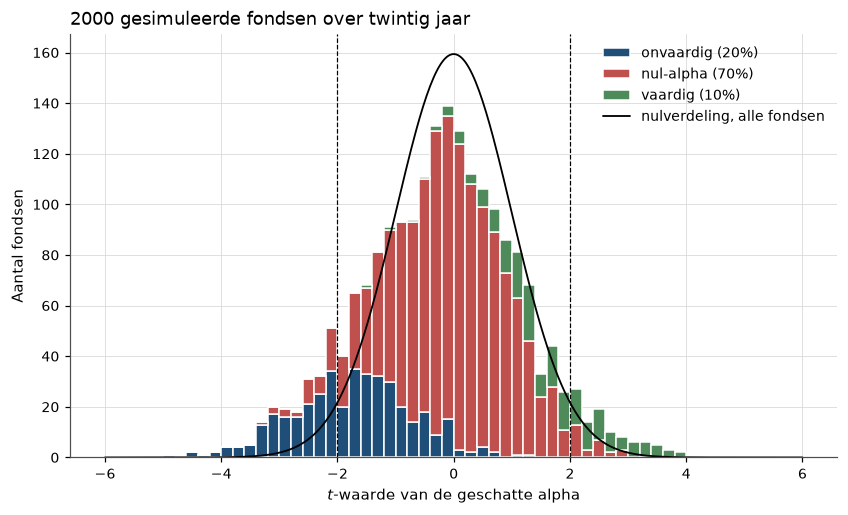

In [5]:
fig, ax = plt.subplots()
bins = np.linspace(-6, 6, 61)
ax.hist([t_sim[groups == g] for g in (2, 0, 1)], bins=bins, stacked=True,
        label=["onvaardig (20%)", "nul-alpha (70%)", "vaardig (10%)"], edgecolor="white")
grid = np.linspace(-6, 6, 400)
ax.plot(grid, stats.t.pdf(grid, 238) * t_sim.size * (bins[1] - bins[0]), color="black",
        lw=1.2, label="nulverdeling, alle fondsen")
for c in (-2, 2):
    ax.axvline(c, color="black", ls="--", lw=0.8)
ax.set_xlabel("$t$-waarde van de geschatte alpha")
ax.set_ylabel("Aantal fondsen")
ax.set_title("2000 gesimuleerde fondsen over twintig jaar")
ax.legend()
plt.show()

:::{figure} #cel-industrie-tverdeling
:label: fig-industrie-tverdeling
:width: 90%

De cross-sectie van $t(\hat\alpha)$ is een mengsel van drie verdelingen die elkaar
grotendeels overlappen. De vaardige fondsen verschuiven de rechterstaart, maar veel
van de fondsen met $t > 2$ zijn nulfondsen met geluk, en de meeste vaardige fondsen
halen de drempel niet.
:::

De tabel laat het probleem in drie getallen zien. Van de 1400 nulfondsen haalt 2,0%
toch $t > 2$, 28 fondsen met geluk; van de 200 vaardige fondsen haalt maar 36% die
drempel. Van de honderd fondsen met $t > 2$ is daardoor ruim een kwart niet vaardig,
en bijna twee derde van de vaardige fondsen blijft onzichtbaar.

### Persistentie: blijft de top de top?

Een belegger die elk jaar de fondsen uit het hoogste kwintiel van vorig jaar koopt,
selecteert op een alpha die over twaalf maanden is geschat. Hoe vaak zit zo'n fonds
het jaar daarna weer in het hoogste kwintiel?

In [6]:
def top_quintile_persistence(Y, F, window=12):
    """Share of top-quintile funds (alpha over one window) that are top again next window."""
    n_windows = Y.shape[0] // window
    alphas = np.array([alpha_tstats(Y[w * window:(w + 1) * window],
                                    F[w * window:(w + 1) * window])[0]
                       for w in range(n_windows)])
    top = alphas >= np.quantile(alphas, 0.8, axis=1, keepdims=True)
    repeat = (top[:-1] & top[1:]).sum(axis=1) / top[:-1].sum(axis=1)
    rank_corr = [stats.spearmanr(alphas[w], alphas[w + 1])[0] for w in range(n_windows - 1)]
    return repeat, np.array(rank_corr), top


repeat, rank_corr, top = top_quintile_persistence(Y_sim, F_sim)
skilled_in_top = np.mean([np.mean(groups[top[w]] == 1) for w in range(top.shape[0])])

pd.DataFrame({
    "waarde": [repeat.mean(), repeat.std(ddof=1) / np.sqrt(repeat.size), 0.2,
               rank_corr.mean(), skilled_in_top, 0.10],
}, index=["kans top -> top", "SE (over jaren)", "kans zonder vaardigheid",
          "gem. rangcorrelatie", "aandeel vaardig in top", "aandeel vaardig totaal"]).round(3)

,waarde
kans top -> top,0.215
SE (over jaren),0.005
kans zonder vaardigheid,0.200
gem. rangcorrelatie,0.028
aandeel vaardig in top,0.164
aandeel vaardig totaal,0.100


Een fonds uit het hoogste kwintiel zit het jaar erna in 21,5% van de gevallen weer
bovenaan, tegen 20% zonder enige vaardigheid, en de gemiddelde rangcorrelatie tussen
opeenvolgende jaren is 0,03. Met negentien overgangen en 2000 fondsen is dat
verschil meetbaar ($t \approx 3$), maar economisch klein: het hoogste kwintiel
bestaat voor 16% uit vaardige fondsen, nauwelijks meer dan hun aandeel van 10% in de
populatie. Echte vaardigheid lijkt in rendementen op het ontbreken ervan, zoals
Carhart vond.

### Wat vinden de bootstrap en de FDR terug?

We passen beide methoden toe alsof we de waarheid niet kenden, met 500
bootstraptrekkingen. Fama en French schatten
zelf geen aandeel vaardige fondsen; om de methoden te kunnen vergelijken, vertalen we
hun vergelijking naar een aantal: het aandeel fondsen boven het 90e percentiel van de
bootstrapverdeling, min de 10% die onder de nul verwacht wordt.

In [7]:
def bootstrap_t(Y, F, n_boot, rng):
    """Fama-French (2010) bootstrap: impose zero alpha, resample months jointly."""
    alpha, t_actual, _ = alpha_tstats(Y, F)
    Y_null = Y - alpha
    T = Y.shape[0]
    t_boot = np.empty((n_boot, Y.shape[1]))
    for b_i in range(n_boot):
        idx = rng.integers(0, T, T)
        t_boot[b_i] = alpha_tstats(Y_null[idx], F[idx])[1]
    return t_actual, t_boot


def compare_percentiles(t_actual, t_boot, pcts):
    """Actual cross-sectional percentiles against their bootstrap distribution."""
    actual = np.percentile(t_actual, pcts)
    simulated = np.percentile(t_boot, pcts, axis=1)          # (len(pcts), n_boot)
    return pd.DataFrame({
        "werkelijk": actual,
        "gem. simulatie": simulated.mean(axis=1),
        "% sim < werkelijk": 100 * (simulated < actual[:, None]).mean(axis=1),
    }, index=[f"p{p}" for p in pcts])


t_actual, t_boot = bootstrap_t(Y_sim, F_sim, 500, rng)
compare_percentiles(t_actual, t_boot, [1, 5, 10, 25, 50, 75, 90, 95, 99]).round(2)

,werkelijk,gem. simulatie,% sim < werkelijk
p1,-3.38,-2.33,0.0
p5,-2.50,-1.65,0.0
p10,-2.01,-1.29,0.0
p25,-1.10,-0.68,0.0
p50,-0.16,-0.00,0.0
p75,0.66,0.68,40.4
p90,1.42,1.29,96.8
p95,2.00,1.65,100.0
p99,3.07,2.33,100.0


In [8]:
def fdr_proportions(t, df, lam=0.5, gamma=0.2):
    """Barras-Scaillet-Wermers (2010) proportions of zero, unskilled and skilled funds."""
    # TODO: naar hap.stats (false discovery rate)
    p = 2 * stats.t.sf(np.abs(t), df)
    pi0 = min(1.0, np.mean(p > lam) / (1 - lam))
    significant = p <= gamma
    pi_minus = np.mean(significant & (t < 0)) - pi0 * gamma / 2
    pi_plus = np.mean(significant & (t > 0)) - pi0 * gamma / 2
    return pi0, pi_minus, pi_plus


def benjamini_hochberg(p, q):
    """Boolean mask of hypotheses rejected by the Benjamini-Hochberg step-up rule."""
    order = np.argsort(p)
    below = p[order] <= q * np.arange(1, p.size + 1) / p.size
    k = below.nonzero()[0].max() + 1 if below.any() else 0
    reject = np.zeros(p.size, dtype=bool)
    reject[order[:k]] = True
    return reject


ff_cutoff = np.percentile(t_boot, 90)
ff_plus = np.mean(t_actual > ff_cutoff) - np.mean(t_boot > ff_cutoff)
pi0, pi_minus, pi_plus = fdr_proportions(t_sim, df=238)

bh = benjamini_hochberg(stats.t.sf(t_sim, 238), q=0.10)
realised_fdp = np.mean(groups[bh] != 1) if bh.any() else np.nan

pd.DataFrame({
    "waarheid": [0.70, 0.20, 0.10, 0.10, np.nan, np.nan],
    "schatting": [pi0, pi_minus, pi_plus, ff_plus, bh.sum(), realised_fdp],
}, index=["pi0 (BSW)", "pi- (BSW)", "pi+ (BSW)", "vaardig (FF-bootstrap)",
          "BH-ontdekkingen, q = 10%", "gerealiseerd aandeel onterecht"]).round(3)

,waarheid,schatting
pi0 (BSW),0.7,0.800
pi- (BSW),0.2,0.131
pi+ (BSW),0.1,0.040
vaardig (FF-bootstrap),0.1,0.020
"BH-ontdekkingen, q = 10%",NaN,16.000
gerealiseerd aandeel onterecht,NaN,0.000


De bootstrap ziet dat er iets aan de hand is: links liggen de werkelijke percentielen
in alle simulaties lager, rechts vanaf het 90e percentiel hoger, het patroon dat Fama
en French beschrijven. Als teller is hij zwak: vertaald naar een aandeel vinden we 2%
vaardig tegen 10% in werkelijkheid. De schatter van Barras, Scaillet en Wermers geeft
$\hat\pi_0 = 0{,}80$ en $\hat\pi_A^+ = 0{,}04$, ook te laag. De oorzaak staat in
{prf:ref}`thm-industrie-pi0`: een vaardig fonds dat niet significant is, telt als
nulfonds. Benjamini-Hochberg vindt 16 vaardige fondsen zonder één onterechte
ontdekking: betrouwbaar, maar 16 van de 200.

Eén universum zegt weinig over een schatter. We herhalen de simulatie daarom
tweehonderd keer, voor steekproeven van tien, twintig en veertig jaar, en kijken naar
de verdeling van $\hat\pi_A^+$.

In [9]:
horizons = [120, 240, 480]
n_universes = 200
pi_plus_draws = {T: np.empty(n_universes) for T in horizons}
pi0_draws = {T: np.empty(n_universes) for T in horizons}
for T in horizons:
    for u in range(n_universes):
        Y_u, F_u, _ = simulate_universe(T, rng)
        t_u = alpha_tstats(Y_u, F_u)[1]
        pi0_draws[T][u], _, pi_plus_draws[T][u] = fdr_proportions(t_u, df=T - 2)

pd.DataFrame({
    "gem. pi0": [pi0_draws[T].mean() for T in horizons],
    "gem. pi+": [pi_plus_draws[T].mean() for T in horizons],
    "SD pi+": [pi_plus_draws[T].std(ddof=1) for T in horizons],
    "5e pct pi+": [np.percentile(pi_plus_draws[T], 5) for T in horizons],
    "95e pct pi+": [np.percentile(pi_plus_draws[T], 95) for T in horizons],
}, index=[f"{T // 12} jaar" for T in horizons]).round(3)

,gem. pi0,gem. pi+,SD pi+,5e pct pi+,95e pct pi+
10 jaar,0.859,0.032,0.008,0.019,0.045
20 jaar,0.786,0.058,0.008,0.045,0.069
40 jaar,0.725,0.085,0.007,0.073,0.096


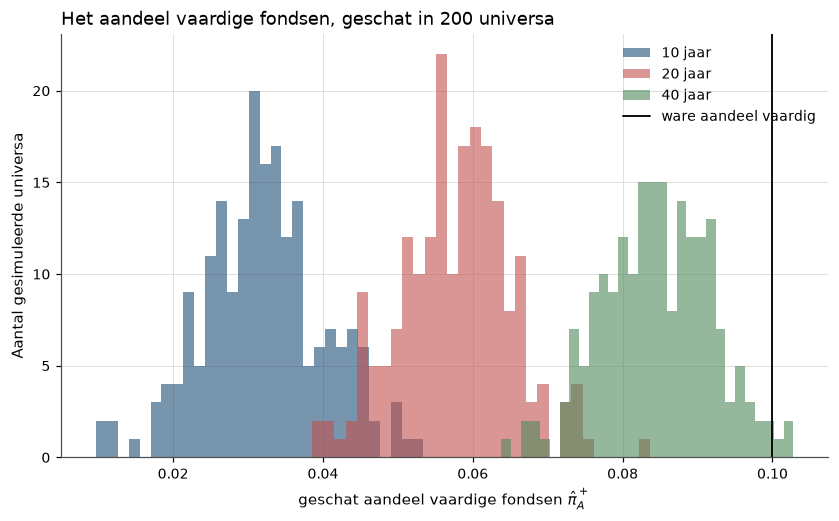

In [10]:
fig, ax = plt.subplots()
for T in horizons:
    ax.hist(pi_plus_draws[T], bins=30, alpha=0.6, label=f"{T // 12} jaar")
ax.axvline(0.10, color="black", lw=1.2, label="ware aandeel vaardig")
ax.set_xlabel("geschat aandeel vaardige fondsen $\\hat\\pi_A^+$")
ax.set_ylabel("Aantal gesimuleerde universa")
ax.set_title("Het aandeel vaardige fondsen, geschat in 200 universa")
ax.legend()
plt.show()

:::{figure} #cel-industrie-fdr
:label: fig-industrie-fdr
:width: 90%

De schatter $\hat\pi_A^+$ varieert weinig tussen universa maar is sterk vertekend:
met tien jaar data vindt hij gemiddeld een derde van de vaardige fondsen, met veertig
jaar 85%. Het probleem is macht, niet ruis, en een laag geschat aandeel vaardige
fondsen is dus ook te lezen als te weinig data.
:::

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Eugene F. Fama en Kenneth R. French, *Luck versus Skill in the
Cross-Section of Mutual Fund Returns*, Journal of Finance 2010
{cite}`FamaFrench2010`; voor persistentie Mark M. Carhart, *On Persistence in
Mutual Fund Performance*, Journal of Finance 1997 {cite}`Carhart1997`.

**Wat.** De gemiddelde nettoalpha van actieve fondsen tegen CAPM, driefactor- en
vierfactormodel; de cross-sectie van $t(\hat\alpha)$ vergeleken met een
bootstrapnul waarin alle alpha's nul zijn en maanden gezamenlijk worden
getrokken (de methode van Fama en French 2010, zie
{prf:ref}`thm-industrie-bootstrap`); en de persistentie van alpha na sortering op de
voorgaande drie jaar.

**Data hier.** Dagelijkse koersen, gecorrigeerd voor uitkeringen en dus na
beheerkosten, van 50 actieve Amerikaanse aandelenfondsen en 6 indexfondsen van
Vanguard, via `hap.data.yahoo(...)`, omgezet naar maandrendementen 1996-01 t/m
2026-07 (367 maanden); factoren via `hap.data.french(...)`.

**Verschil met het origineel.** Fama en French en Carhart gebruikten de CRSP
Survivor-Bias-Free Mutual Fund Database met duizenden fondsen, inclusief
opgeheven en samengevoegde fondsen. Wij hebben 50 fondsen die we *vandaag* kennen
omdat ze nog bestaan en groot zijn: een steekproef van overlevers, met de bias uit
[](#02-05-crsp-tape) in het voordeel van de fondsen {cite}`BrownGoetzmannIbbotsonRoss1992`.
Omdat 50 fondsen geen staart hebben, vergelijken we percentielen tussen het 5e en
95e, niet het 1e en 99e.

**Verwachte afwijking.** De schone controle is het totale-marktindexfonds
(VTSMX): zijn alpha moet negatief zijn en niet groter dan enkele tienden procent per
jaar, de orde van zijn kosten. Indexfondsen op een deel van de markt hoeven dat niet,
want hun index is geen combinatie van French-factoren. Zonder selectie zou de
gemiddelde nettoalpha van actieve fondsen rond min de kosten liggen, ruwweg
$-0{,}5$ tot $-1\%$ per jaar; door de survivorship bias verwachten wij een hoger
gemiddelde, binnen één procentpunt van nul en zonder significante alpha voor de
gelijkgewogen portefeuille. De bootstrap moet dezelfde optimistische verschuiving
tonen: werkelijke percentielen boven de gesimuleerde. Persistentie: het verschil in
alpha tussen het hoogste en laagste terciel mag geen $t$-waarde boven 2 hebben. Is de
alpha van het totale-marktindexfonds positief, dan zit er een fout in de code.
```

```{warning}
Fondsen die sinds 1996 slecht presteerden, zijn opgeheven of opgegaan in andere
fondsen en ontbreken hier. Elke alpha in deze sectie is daarom een bovengrens voor
wat een belegger met een willekeurig fonds uit 1996 verdiende.
```

In [11]:
tickers = (
    "FDGRX FLPSX FEQIX FDVLX FBGRX FOCPX FTRNX FFIDX FDCAX FGRIX FMCSX FDSSX FMAGX FCNTX "
    "AGTHX AIVSX ANCFX AMCPX AWSHX AMRMX PRGFX PRNHX TRBCX PRFDX PRDGX RPMGX PRWAX TRVLX "
    "VWNDX VWNFX VWUSX VPMCX VEIPX VQNPX VEXPX VMRGX VHCOX DODGX TWCUX TWCGX JANSX SEQUX "
    "MUTHX FKGRX NYVTX OAKMX PENNX MPGFX NBGNX HACAX PRBLX LMVTX CGMFX "
    "VFINX VTSMX NAESX VIVAX VIGRX VEXMX"
).split()
index_funds = {
    "VFINX": "Vanguard 500 Index", "VTSMX": "Vanguard Total Stock Market Index",
    "NAESX": "Vanguard Small-Cap Index", "VIVAX": "Vanguard Value Index",
    "VIGRX": "Vanguard Growth Index", "VEXMX": "Vanguard Extended Market Index",
}

prices = hap_data.yahoo(tickers, "1985-01-01").resample("ME").last()
fund_ret = (prices / prices.shift(1) - 1).iloc[1:]
factors = hap_data.french("F-F_Research_Data_Factors").join(hap_data.french("F-F_Momentum_Factor"))

sample = fund_ret.index.intersection(factors.index)
sample = sample[sample >= "1996-01-01"]
excess = fund_ret.loc[sample].sub(factors.loc[sample, "RF"], axis=0).dropna(axis=1)
fac = factors.loc[sample]
active_cols = [c for c in excess.columns if c not in index_funds]

print(f"{sample[0]:%Y-%m} t/m {sample[-1]:%Y-%m}: {len(sample)} maanden, "
      f"{len(active_cols)} actieve fondsen, {excess.shape[1] - len(active_cols)} indexfondsen")
print("weggevallen (te korte historie):", sorted(set(tickers) - set(excess.columns)))

1996-01 t/m 2026-07: 367 maanden, 50 actieve fondsen, 6 indexfondsen
weggevallen (te korte historie): ['CGMFX', 'JANSX', 'VMRGX']


In [12]:
models = {"CAPM": ["Mkt-RF"], "FF3": ["Mkt-RF", "SMB", "HML"],
          "Carhart": ["Mkt-RF", "SMB", "HML", "Mom"]}
Y_act = excess[active_cols].to_numpy()
ew_active = Y_act.mean(axis=1, keepdims=True)

rows = {}
for name, cols in models.items():
    F = fac[cols].to_numpy()
    a_act, t_act, _ = alpha_tstats(Y_act, F)
    a_ew, t_ew, _ = alpha_tstats(ew_active, F)
    a_idx, t_idx, _ = alpha_tstats(excess[list(index_funds)].to_numpy(), F)
    rows[name] = {
        "actief: gem. alpha (%/jr)": 1200 * a_act.mean(),
        "actief: mediaan t": np.median(t_act),
        "actief: aandeel t > 2": np.mean(t_act > 2),
        "actief: aandeel t < -2": np.mean(t_act < -2),
        "EW-portefeuille actief: alpha (%/jr)": 1200 * a_ew[0],
        "EW-portefeuille actief: t": t_ew[0],
        **{f"{index_funds[k]}: alpha (%/jr)": 1200 * v for k, v in zip(index_funds, a_idx)},
        "VFINX: t": t_idx[0],
    }
performance = pd.DataFrame(rows)
performance.round(2)

,CAPM,FF3,Carhart
actief: gem. alpha (%/jr),0.54,0.41,0.53
actief: mediaan t,0.36,0.51,0.74
actief: aandeel t > 2,0.06,0.14,0.14
actief: aandeel t < -2,0.00,0.06,0.04
EW-portefeuille actief: alpha (%/jr),0.54,0.41,0.53
EW-portefeuille actief: t,1.32,1.05,1.36
Vanguard 500 Index: alpha (%/jr),0.14,-0.11,0.03
Vanguard Total Stock Market Index: alpha (%/jr),-0.19,-0.24,-0.22
Vanguard Small-Cap Index: alpha (%/jr),-1.15,-1.05,-1.02
Vanguard Value Index: alpha (%/jr),-0.09,-1.16,-0.61


Het totale-marktindexfonds VTSMX heeft de verwachte alpha: $-0{,}19\%$ per jaar tegen
het CAPM. Het S&P 500-fonds VFINX heeft een kleine positieve CAPM-alpha ($0{,}14\%$,
$t = 0{,}33$), omdat grote ondernemingen in deze periode de bredere markt versloegen,
en de small-cap- en extended-marketfondsen blijven ruim één procent per jaar achter
bij de factormodellen. Dat zijn geen slechte beheerders maar benchmarks die niemand
kan kopen: SMB en HML zijn papieren portefeuilles zonder kosten, en daarom meten
{cite:t}`BerkVanBinsbergen2015` vaardigheid tegen indexfondsen. De 50 overlevende
actieve fondsen halen gemiddeld ongeveer $+0{,}5\%$ per jaar; hun gelijkgewogen
portefeuille heeft een Carhart-alpha van $0{,}53\%$ met $t = 1{,}36$, en 14% van de
fondsen haalt $t > 2$. Dat is ruim één procentpunt boven de $-0{,}67\%$ die de
kostenschatting van French voor de gemiddelde actieve dollar geeft: de maat van wat
selectie op overleven kan doen, die we hier kunnen benoemen maar niet meten.

In [13]:
F_c4 = fac[models["Carhart"]].to_numpy()
t_real, t_real_boot = bootstrap_t(Y_act, F_c4, 2000, rng)
compare_percentiles(t_real, t_real_boot, [5, 10, 25, 50, 75, 90, 95]).round(2)

,werkelijk,gem. simulatie,% sim < werkelijk
p5,-1.73,-1.47,29.45
p10,-1.12,-1.18,53.25
p25,-0.38,-0.65,71.05
p50,0.74,-0.03,95.45
p75,1.09,0.60,85.00
p90,2.12,1.13,96.55
p95,2.25,1.43,93.80


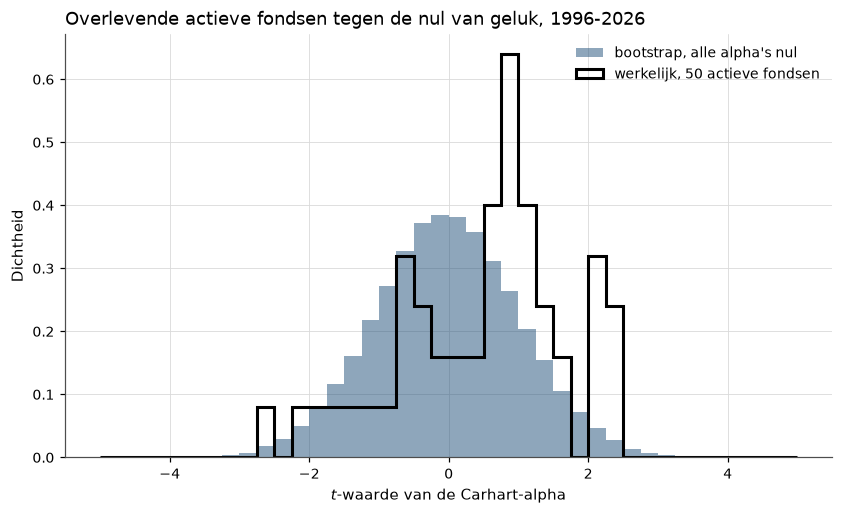

In [14]:
fig, ax = plt.subplots()
bins = np.linspace(-5, 5, 41)
ax.hist(t_real_boot.ravel(), bins=bins, density=True, alpha=0.5,
        label="bootstrap, alle alpha's nul")
ax.hist(t_real, bins=bins, density=True, histtype="step", lw=2, color="black",
        label=f"werkelijk, {len(active_cols)} actieve fondsen")
ax.set_xlabel("$t$-waarde van de Carhart-alpha")
ax.set_ylabel("Dichtheid")
ax.set_title("Overlevende actieve fondsen tegen de nul van geluk, 1996-2026")
ax.legend()
plt.show()

:::{figure} #cel-industrie-bootstrap-echt
:label: fig-industrie-bootstrap-echt
:width: 90%

De hele verdeling van werkelijke $t$-waarden ligt rechts van de nul van geluk: de
mediaan is $0{,}74$ tegen $-0{,}03$ in de simulaties, hoger dan in 95% van de
trekkingen. Dat is de handtekening van een steekproef die op succes is geselecteerd,
niet per se van vaardigheid.
:::

Tot slot de persistentie. Elk jaar van 1999 tot en met 2025 schatten we de
Carhart-alpha van elk actief fonds over de voorgaande 36 maanden, delen de fondsen in
tercielen, en meten het abnormale rendement in het jaar daarna met de bèta's uit de
vormingsperiode, zodat er in de evaluatie niets wordt geschat.

In [15]:
years = range(1999, 2026)
spread, top_alpha, bottom_alpha, rank_corr_real = [], [], [], []
for year in years:
    form = (excess.index >= f"{year - 3}-01-01") & (excess.index < f"{year}-01-01")
    evaluate = (excess.index >= f"{year}-01-01") & (excess.index < f"{year + 1}-01-01")
    a_form, _, betas = alpha_tstats(Y_act[form], F_c4[form])
    abnormal = 12 * (Y_act[evaluate] - F_c4[evaluate] @ betas).mean(axis=0)
    ranks = pd.qcut(a_form, 3, labels=False)
    top_alpha.append(abnormal[ranks == 2].mean())
    bottom_alpha.append(abnormal[ranks == 0].mean())
    spread.append(top_alpha[-1] - bottom_alpha[-1])
    rank_corr_real.append(stats.spearmanr(a_form, abnormal)[0])

spread = np.array(spread)
pd.DataFrame({
    "gemiddelde": [100 * np.mean(top_alpha), 100 * np.mean(bottom_alpha), 100 * spread.mean(),
                   np.mean(rank_corr_real)],
    "SE": [100 * np.std(top_alpha, ddof=1) / np.sqrt(len(spread)),
           100 * np.std(bottom_alpha, ddof=1) / np.sqrt(len(spread)),
           100 * spread.std(ddof=1) / np.sqrt(len(spread)),
           np.std(rank_corr_real, ddof=1) / np.sqrt(len(spread))],
}, index=["hoogste terciel: alpha volgend jaar (%)", "laagste terciel: alpha volgend jaar (%)",
          "verschil hoog - laag (%)", "rangcorrelatie vorming-evaluatie"]).assign(
    t=lambda d: d["gemiddelde"] / d["SE"]).round(2)

,gemiddelde,SE,t
hoogste terciel: alpha volgend jaar (%),0.13,0.79,0.17
laagste terciel: alpha volgend jaar (%),-0.37,0.57,-0.66
verschil hoog - laag (%),0.51,0.59,0.86
rangcorrelatie vorming-evaluatie,0.05,0.04,1.18


Het hoogste terciel van de voorgaande drie jaar haalt het jaar daarna gemiddeld
$0{,}13\%$ alpha, het laagste $-0{,}37\%$. Het verschil van $0{,}51$ procentpunt heeft
over 27 jaar een standaardfout van $0{,}59$ ($t = 0{,}86$), en de rangcorrelatie
tussen vormings- en evaluatie-alpha is $0{,}05$. Er is geen persistentie die van nul
te onderscheiden is, zoals verwacht. Dat bewijst niet dat ze er niet is: een verschil
van een half procent per jaar zou bij deze spreiding pas na ongeveer 145 jaar een
$t$-waarde van 2 halen.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Sharpes rekenkunde en het model van Berk en Green
verklaren samen de drie hardnekkigste feiten over de beleggingsindustrie: de
gemiddelde actieve dollar blijft na kosten achter, ongeveer met de $0{,}67\%$ die
French telde; winnaars blijven geen winnaars, in Carharts 1892 fondsen en in onze
tercielen; en geld stroomt toch achter winnaars aan. Ze verklaren ook de sociologie:
Booth, Sinquefield en Asness hoefden de rekenkunde niet te weerleggen om een bedrijf
te bouwen, want die zegt niets over wie wint en alles over wat het kost. Eind 2019
bezaten indexfondsen evenveel van de Amerikaanse beurs als actieve aandelenfondsen.

**Waar het breekt.** Bij het meten van vaardigheid zelf. In onze simulatie met 10%
vaardige fondsen vond de beste schatter met twintig jaar data er gemiddeld 6%, en
onze echte steekproef levert een bootstrap die op vaardigheid lijkt maar door
selectie op overleven niet te interpreteren is. Barras, Scaillet en Wermers zagen het
aandeel vaardige fondsen tussen 1996 en 2006 naar bijna nul dalen; of de vaardigheid
verdween of de toets zijn macht verloor, laat de data niet zien.

**Risico of vergissing?** De Chicago-lezing: kapitaal is net zo concurrerend als
informatie; vaardigheid bestaat en wordt beloond in vergoedingen, en dat beleggers
geen alpha zien is het bewijs van evenwicht. Wat DFA en AQR verkopen, is dan een
vergoeding voor beprijsd risico. De Yale-lezing: beleggers jagen rendementen na die
ze niet kunnen beoordelen, betalen kosten die ze niet zien en handelen te veel; de
premies achter DFA en AQR zijn vergissingen van anderen, en dure fondsen overleven
omdat hun klanten de rekenkunde niet kennen. Scheiden zou kunnen met data over
waarop beleggers hun kapitaalstromen baseren en met benchmarks die men werkelijk kan
kopen; het eerste is omstreden, het tweede bestaat pas sinds indexfondsen goedkoop
zijn. Santa-Clara's praktijkles past op beide lezingen: wie een indexfonds koopt,
draagt beprijsd risico; wie een actief fonds koopt, denkt iets te weten wat de prijs
niet weet, of betaalt iemand die dat denkt.

**Wat er daarna kwam.** Elke alpha in deze lecture werd gemeten tegen een
factormodel, en de keuze van dat model bepaalde het antwoord. De volgende lecture
laat zien dat elk zulk model een uitspraak is over één *stochastic discount factor*
(SDF, de random variabele waarmee alle payoffs worden verdisconteerd):
[](#05-26-sdf-unificatie).

## Oefeningen

:::{exercise}
:label: ex-industrie-1

**Rekenkunde met particulieren.** In een markt bezitten indexbeleggers 30%,
beleggingsfondsen 30% en particuliere actieve beleggers 40% van alle aandelen.
Particulieren halen bruto gemiddeld $2\%$ per jaar minder dan de markt, zoals in de
handelsdata van {cite:t}`BarberOdean2000`.

1. Welke gemiddelde bruto alpha moeten de fondsen dan halen?
2. Fondsen rekenen $1\%$ kosten, indexfondsen $0{,}1\%$. Wat is het verschil in
   nettorendement tussen de gemiddelde fondsbelegger en de indexbelegger?
3. Bewijs dat de gemiddelde bruto alpha van de fondsen nul is zodra de particulieren
   óók passief worden.
:::

:::{solution} ex-industrie-1
:class: dropdown

Pas {prf:ref}`thm-industrie-sharpe` toe op de actieve beleggers samen: hun
vermogensgewogen alpha is nul, dus $0{,}4 \times (-2\%) + 0{,}3\, a_F = 0$ en
$a_F = 0{,}8/0{,}3 = 2{,}67\%$. Na kosten haalt de fondsbelegger $2{,}67 - 1 = 1{,}67\%$
boven de markt, tegen $-0{,}1\%$ voor de indexbelegger: een voorsprong van
$1{,}77$ procentpunt. Worden de particulieren passief, dan bestaat $\mathcal{A}$ alleen
uit fondsen, en zegt de propositie dat hun gewogen bruto alpha nul is.

In [16]:
w_index, w_funds, w_retail = 0.30, 0.30, 0.40
alpha_retail = -0.02
alpha_funds = -w_retail * alpha_retail / w_funds
print(f"bruto alpha fondsen          : {alpha_funds:.4%}")
print(f"netto voorsprong op de index : {(alpha_funds - 0.01) - (-0.001):.4%}")

bruto alpha fondsen          : 2.6667%
netto voorsprong op de index : 1.7667%


De rekenkunde verbiedt niet dat fondsen winnen; ze zegt wie er dan verliest. Dat het
in de data meestal de fondsbeleggers zijn, is een empirisch feit, geen stelling.
:::

:::{exercise}
:label: ex-industrie-2

**Berk en Green met kwadratische kosten.** Neem $C(q) = b q^2$ met $b = 0{,}005$ per
miljard, $f = 1\%$, een prior $\phi_0 = 3\%$ met standaarddeviatie $\eta = 1\%$, en een
ruis $\sigma = 5\%$ per jaar.

1. Leid af dat $q_t = \phi_t^2/(4bf)$ en dat die oplossing alleen geldt als
   $\phi_t \geq 2f$.
2. Het fonds haalt in het eerste jaar $R_1 = 8\%$. Bereken $\phi_1$, de nieuwe omvang en
   de procentuele instroom.
3. Wat is het verwachte rendement voor de belegger in jaar 2, en waarom is dat niet in
   strijd met de instroom?
:::

:::{solution} ex-industrie-2
:class: dropdown

**(1)** $C'(q_a) = 2bq_a = \phi_t$ geeft $q_a = \phi_t/(2b)$. De bindende
participatievoorwaarde geeft $f q_t = \phi_t q_a - b q_a^2 = \phi_t^2/(2b) - \phi_t^2/(4b)
= \phi_t^2/(4b)$. De indexpositie $q_t - q_a = \phi_t(\phi_t - 2f)/(4bf)$ is niet negatief
als en slechts als $\phi_t \geq 2f$.

**(2)** Met $\gamma = 1/0{,}01^2 = 10\,000$ en $\omega = 1/0{,}05^2 = 400$ is
$\phi_1 = (10\,000 \times 0{,}03 + 400 \times 0{,}08)/10\,400 = 3{,}19\%$.

In [17]:
b_bg, f_bg, phi0, eta, sigma, R1 = 0.005, 0.01, 0.03, 0.01, 0.05, 0.08
gamma_p, omega_p = 1 / eta**2, 1 / sigma**2
phi1 = (gamma_p * phi0 + omega_p * R1) / (gamma_p + omega_p)
q0, q1 = phi0**2 / (4 * b_bg * f_bg), phi1**2 / (4 * b_bg * f_bg)
print(f"phi_1 = {phi1:.4%}, q_0 = {q0:.3f} mld, q_1 = {q1:.3f} mld, instroom = {q1 / q0 - 1:.1%}")

phi_1 = 3.1923%, q_0 = 4.500 mld, q_1 = 5.095 mld, instroom = 13.2%


**(3)** Nul: de instroom zet de omvang precies zo dat $\E_1[r_2] = 0$. Een rendement
van vijf procentpunt boven de verwachting verhoogt de geschatte vaardigheid met
0,19 procentpunt en de omvang met 13%, en daarna is het fonds weer "gewoon". De
oefening laat zien waarom geld dat rendementen najaagt rationeel kan zijn en toch
niets oplevert.
:::

:::{exercise}
:label: ex-industrie-3

**False discoveries in de echte fondsen.** Gebruik de Carhart-$t$-waarden van de 50
actieve fondsen uit de replicatie.

1. Schat $\hat\pi_0$, $\hat\pi_A^-$ en $\hat\pi_A^+$ met $\lambda = 0{,}5$ en $\gamma = 0{,}2$.
2. Hoeveel fondsen verwerpt Benjamini-Hochberg met $q = 10\%$ als "vaardig" (eenzijdige
   p-waarden)?
3. Bereken met de simulatie-uitkomst voor veertig jaar de standaardfout van $\hat\pi_A^+$ bij
   2000 fondsen, en schaal die naar 51 fondsen. Wat kun je uit (1) concluderen?
:::

:::{solution} ex-industrie-3
:class: dropdown

In [18]:
df_real = len(sample) - 5
pi0_r, pim_r, pip_r = fdr_proportions(t_real, df=df_real)
bh_real = benjamini_hochberg(stats.t.sf(t_real, df_real), q=0.10)
se_2000 = pi_plus_draws[480].std(ddof=1)
print(f"pi0 = {pi0_r:.2f}, pi- = {pim_r:.2f}, pi+ = {pip_r:.2f}")
print(f"BH-ontdekkingen (q = 10%): {bh_real.sum()} van {len(t_real)}")
print(f"SE pi+ bij 2000 fondsen (40 jaar): {se_2000:.3f}; "
      f"geschaald naar {len(t_real)} fondsen: {se_2000 * np.sqrt(2000 / len(t_real)):.3f}")

pi0 = 0.60, pi- = 0.02, pi+ = 0.18
BH-ontdekkingen (q = 10%): 0 van 50
SE pi+ bij 2000 fondsen (40 jaar): 0.007; geschaald naar 50 fondsen: 0.046


Op de overlevers geeft de schatter $\hat\pi_0 = 0{,}60$ en $\hat\pi_A^+ = 0{,}18$,
maar Benjamini-Hochberg vindt geen enkel vaardig fonds. De standaardfout van
$\hat\pi_A^+$ is bij 50 fondsen ongeveer $0{,}05$, zes keer zo groot als bij 2000
fondsen, en de steekproef is op succes geselecteerd. De oefening laat zien dat een
geschat aandeel vaardige fondsen alleen iets betekent in een groot universum zonder
survivorship bias: precies de data die hier ontbreekt.
:::